In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
netflix_dataset = pd.read_csv('/content/combined_data_1.txt',header=None,names=['Cust_Id', 'Rating'],usecols=[0,1])

netflix_dataset.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [3]:
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [4]:
netflix_dataset.dtypes

,0
Cust_Id,object
Rating,float64


In [5]:
netflix_dataset.shape

(24058263, 2)

In [6]:
movie_count=netflix_dataset.isnull().sum()
movie_count

,0
Cust_Id,0
Rating,4499


In [7]:
customer_count=netflix_dataset['Cust_Id'].nunique()

In [8]:
customer_count

475257

In [9]:
customer_count=netflix_dataset['Cust_Id'].nunique()-movie_count
customer_count

,0
Cust_Id,475257
Rating,470758


In [10]:
rating_count=netflix_dataset['Cust_Id'].count()-movie_count
rating_count

,0
Cust_Id,24058263
Rating,24053764


In [11]:
stars=netflix_dataset.groupby('Rating')['Rating'].agg(['count'])

In [12]:
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


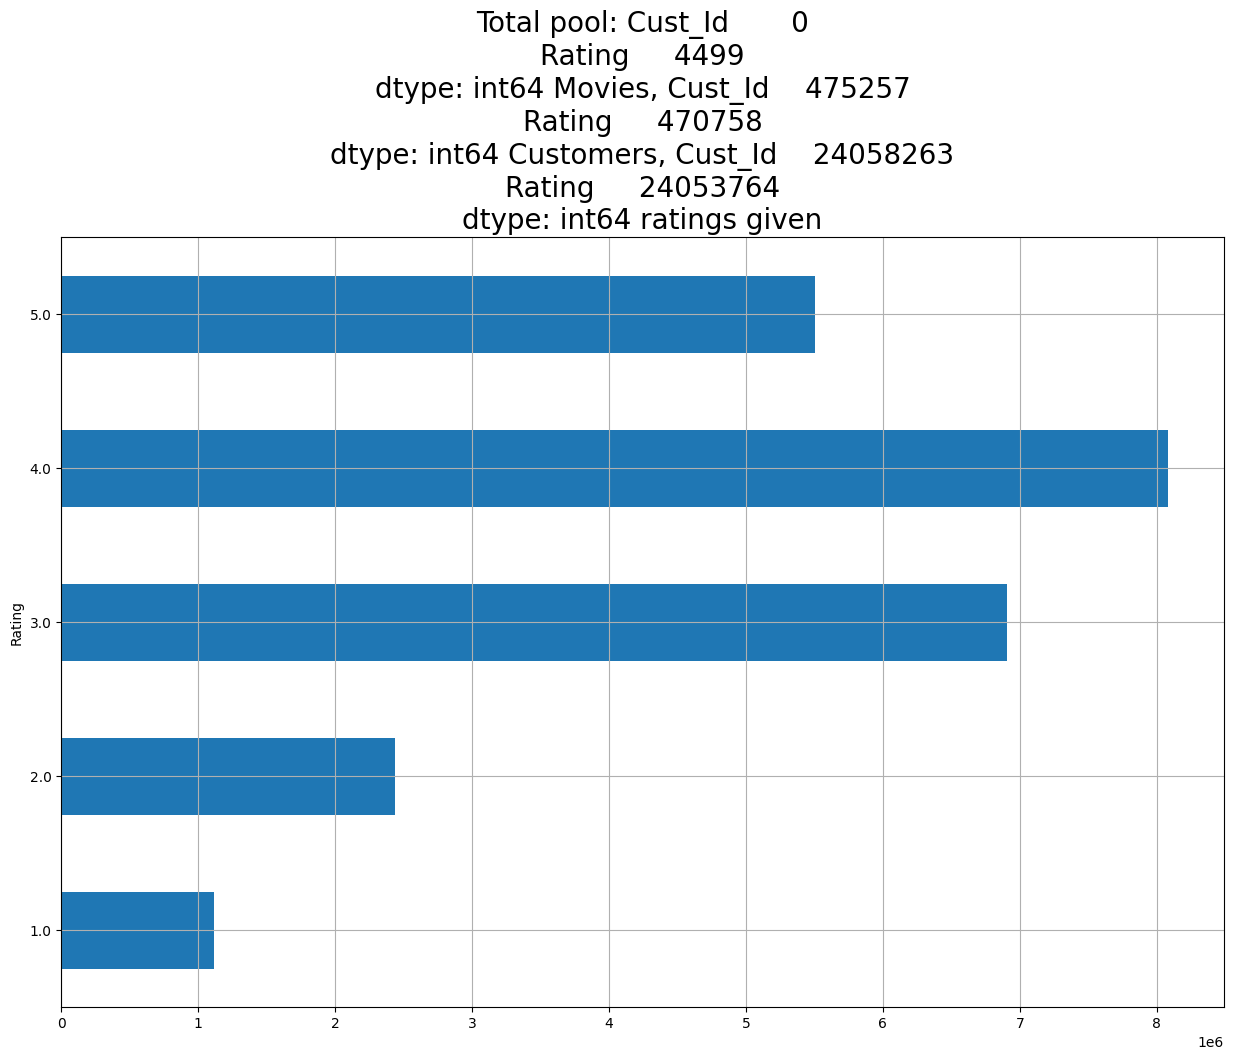

In [13]:
ax=stars.plot(kind='barh', legend=False, figsize=(15,10))
plt.title(f'Total pool: {movie_count} Movies, {customer_count} Customers, {rating_count} ratings given', fontsize=20)
plt.grid(True)

In [14]:
#add another column that will have movie id
#first of all we will be calculating how many null values we are having in the ratings column
df_nan=pd.DataFrame(pd.isnull(netflix_dataset.Rating))

In [15]:
df_nan

,Rating
0,True
1,False
2,False
3,False
4,False
...,...
24058258,False
24058259,False
24058260,False
24058261,False


In [16]:
df_nan=df_nan[df_nan['Rating']==True]
df_nan

,Rating
0,True
548,True
694,True
2707,True
2850,True
...,...
24046714,True
24047329,True
24056849,True
24057564,True


In [17]:
df_nan.shape

(4499, 1)

In [18]:
df_nan.head()

,Rating
0,True
548,True
694,True
2707,True
2850,True


In [19]:
#now we will reset the index as the column
df_nan=df_nan.reset_index()

In [20]:
df_nan

,index,Rating
0,0,True
1,548,True
2,694,True
3,2707,True
4,2850,True
...,...,...
4494,24046714,True
4495,24047329,True
4496,24056849,True
4497,24057564,True


In [21]:
#To create a numpy array containing movie ids according the 'ratings' dataset

movie_np = []
movie_id = 1

for i,j in zip(df_nan['index'][1:],df_nan['index'][:-1]):
    # numpy approach
    temp = np.full((1,i-j-1), movie_id)
    movie_np = np.append(movie_np, temp)
    movie_id += 1



In [22]:
movie_np

array([1.000e+00, 1.000e+00, 1.000e+00, ..., 4.498e+03, 4.498e+03,
       4.498e+03])

In [23]:
df_nan.iloc[-1, 0]

24057834

In [24]:
len(netflix_dataset)

24058263

In [25]:
# Account for last record and corresponding length
# numpy approach
last_record = np.full((1,len(netflix_dataset) - df_nan.iloc[-1, 0] - 1),movie_id)
movie_np = np.append(movie_np, last_record)

print(f'Movie numpy: {movie_np}')
print(f'Length: {len(movie_np)}')

Movie numpy: [1.000e+00 1.000e+00 1.000e+00 ... 4.499e+03 4.499e+03 4.499e+03]
Length: 24053764


In [26]:
df_nan['index'][1:]

,index
1,548
2,694
3,2707
4,2850
5,3991
...,...
4494,24046714
4495,24047329
4496,24056849
4497,24057564


In [27]:
x=zip(df_nan['index'][1:], df_nan['index'][:-1])

In [28]:
tuple(x)

((548, 0),
 (694, 548),
 (2707, 694),
 (2850, 2707),
 (3991, 2850),
 (5011, 3991),
 (5105, 5011),
 (20016, 5105),
 (20112, 20016),
 (20362, 20112),
 (20561, 20362),
 (21108, 20561),
 (21234, 21108),
 (21353, 21234),
 (21644, 21353),
 (24344, 21644),
 (31453, 24344),
 (42176, 31453),
 (42716, 42176),
 (42833, 42716),
 (43052, 42833),
 (43256, 43052),
 (43872, 43256),
 (45206, 43872),
 (46414, 45206),
 (52276, 46414),
 (52550, 52276),
 (92303, 52550),
 (92827, 92303),
 (211241, 92827),
 (211463, 211241),
 (213318, 211463),
 (220209, 213318),
 (220318, 220209),
 (221158, 220318),
 (222098, 221158),
 (222380, 222098),
 (223183, 222380),
 (223936, 223183),
 (224428, 223936),
 (224522, 224428),
 (224651, 224522),
 (224757, 224651),
 (233259, 224757),
 (235879, 233259),
 (242438, 235879),
 (244789, 242438),
 (248381, 244789),
 (248613, 248381),
 (248942, 248613),
 (249033, 248942),
 (254181, 249033),
 (254296, 254181),
 (254456, 254296),
 (256863, 254456),
 (258697, 256863),
 (262260, 258697)

In [29]:
temp=np.full((1,500), 8) #(shape, fill_value)

In [30]:
print(temp)

[[8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
  8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 

In [31]:
netflix_dataset=netflix_dataset[pd.notnull(netflix_dataset['Rating'])]
netflix_dataset['Movie_Id']=movie_np.astype(int)
netflix_dataset['Cust_Id']=netflix_dataset['Cust_Id'].astype(int)
print("Now the dataset will look like: ")
netflix_dataset.head()

/tmp/ipykernel_25404/2298727202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset['Movie_Id']=movie_np.astype(int)


Now the dataset will look like: 


/tmp/ipykernel_25404/2298727202.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset['Cust_Id']=netflix_dataset['Cust_Id'].astype(int)


,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [32]:
#now we will remove all the users that have rated less movies and
#also all those movies that has been rated less in numbers
f=['count','mean']

In [33]:
dataset_movie_summary=netflix_dataset.groupby('Movie_Id').agg(f)

In [34]:
dataset_movie_summary

Cust_Id               Rating          
           count          mean  count      mean
Movie_Id                                       
1            547  1.249876e+06    547  3.749543
2            145  1.341926e+06    145  3.558621
3           2012  1.324290e+06   2012  3.641153
4            142  1.402854e+06    142  2.739437
5           1140  1.302384e+06   1140  3.919298
...          ...           ...    ...       ...
4495         614  1.321093e+06    614  3.478827
4496        9519  1.332006e+06   9519  3.763000
4497         714  1.330543e+06    714  2.715686
4498         269  1.262035e+06    269  2.464684
4499         428  1.270551e+06    428  2.614486

[4499 rows x 4 columns]

In [35]:
dataset_movie_summary=netflix_dataset.groupby('Movie_Id')['Rating'].agg(f)

In [36]:
dataset_movie_summary

,count,mean
Movie_Id,,
1,547,3.749543
2,145,3.558621
3,2012,3.641153
4,142,2.739437
5,1140,3.919298
...,...,...
4495,614,3.478827
4496,9519,3.763000
4497,714,2.715686


In [37]:
dataset_movie_summary["count"].quantile(0.7)

1798.6

In [38]:
#now we will create a benchmark
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.7),0)
movie_benchmark

1799.0

In [39]:
dataset_movie_summary['count']

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [40]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list

Index([   1,    2,    4,    5,    6,    7,    9,   10,   11,   12,
       ...
       4484, 4486, 4487, 4489, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=3149)

In [41]:
#now we will remove all the users that are in-active
dataset_cust_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(f)
dataset_cust_summary

,count,mean
Cust_Id,,
6,153,3.333333
7,195,4.066667
8,21,4.000000
10,49,3.346939
25,4,3.500000
...,...,...
2649404,12,4.083333
2649409,10,4.000000
2649421,3,5.000000


In [42]:
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.7),0)
cust_benchmark

52.0

In [43]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      10,      25,      33,      42,      59,      83,      87,
            94,     116,
       ...
       2649343, 2649351, 2649375, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=327300)

In [44]:
print('The original dataframe has: ', netflix_dataset.shape, 'shape')

The original dataframe has:  (24053764, 3) shape


In [45]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]
print('After the triming, the shape is: {}'.format(netflix_dataset.shape))

After the triming, the shape is: (17337458, 3)


In [46]:
df_title = pd.read_csv("movie_titles.csv",  encoding='ISO-8859-1', header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

df_title.set_index('Movie_Id', inplace=True)

In [47]:

df_title

,Year,Name
Movie_Id,,
1,2003.0,Dinosaur Planet
2,2004.0,Isle of Man TT 2004 Review
3,1997.0,Character
4,1994.0,Paula Abdul's Get Up & Dance
5,2004.0,The Rise and Fall of ECW
...,...,...
17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17767,2004.0,Fidel Castro: American Experience
17768,2000.0,Epoch


In [50]:
netflix_dataset_pivot = netflix_dataset.pivot_table(
    index='Cust_Id',
    columns='Movie_Id',
    values='Rating'
)
netflix_dataset_pivot.head()

Movie_Id,3,8,16,17,18,26,28,30,32,33,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
Cust_Id,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,5.0,NaN,NaN,NaN,NaN,4.0,5.0,NaN,NaN,...,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
#Convert the pivot table to a scipy sparse matrix before feeding it into the model.

from scipy.sparse import csr_matrix

netflix_dataset_pivot_sparse = csr_matrix(netflix_dataset_pivot.fillna(0).values)

In [53]:
# Train with SVD (Matrix Factorization)
# Truncated SVD to decompose the sparse matrix into latent factors.
from sklearn.decomposition import TruncatedSVD

SVD = TruncatedSVD(n_components=12, random_state=17)
matrix = SVD.fit_transform(netflix_dataset_pivot_sparse)
matrix.shape  # (num_customers, 12)


(143458, 12)

In [54]:
# Calculate cosine correlation between all movie vectors.
import warnings
warnings.filterwarnings('ignore')

corr = np.corrcoef(matrix.T)   # shape: (num_movies, num_movies)
corr.shape

(12, 12)

In [57]:
def recommend_movies(movie_title, num_recommendations=10):
    # Find Movie_Id from title
    movie_id_row = df_title[df_title['Name'] == movie_title]

    if movie_id_row.empty:
        return f"Movie '{movie_title}' not found in the dataset."

    movie_id = movie_id_row.index[0]

    # Check if movie_id exists in the pivot table's columns
    if movie_id not in netflix_dataset_pivot.columns:
        return f"Movie '{movie_title}' was filtered out due to insufficient ratings."

    # Map Movie_Id to pivot column index
    movie_col_index = list(netflix_dataset_pivot.columns).index(movie_id)

    # Get correlations for that movie
    corr_movie = corr[movie_col_index]

    # Get top N most correlated movie indices (excluding itself)
    # Ensure there are enough correlations to select from after removing self
    if len(corr_movie) <= 1:
        return f"Not enough correlations found for movie '{movie_title}'."

    top_indices = corr_movie.argsort()[::-1][1:num_recommendations+1]

    # Map back to Movie_Id and fetch titles
    top_movie_ids = netflix_dataset_pivot.columns[top_indices]
    recommendations = df_title.loc[df_title.index.isin(top_movie_ids), 'Name']

    return recommendations

recommend_movies("What the #$*! Do We Know!?")

,Name
Movie_Id,
16,Screamers
17,7 Seconds
18,Immortal Beloved
26,Never Die Alone
28,Lilo and Stitch
30,Something's Gotta Give
32,ABC Primetime: Mel Gibson's The Passion of the...
33,Aqua Teen Hunger Force: Vol. 1
44,Spitfire Grill


In [60]:
#Write a few structured tests to validate your system is working.

# Test 1: Does it return the right number of results?
results = recommend_movies("What the #$*! Do We Know!?", num_recommendations=5)
if isinstance(results, str): # Handle error messages from the function
    print(f"Test 1 skipped due to: {results}")
else:
    assert len(results) == 5, "Should return exactly 5 recommendations"

# Test 2: Does it NOT recommend the movie itself?
movie_name = "What the #$*! Do We Know!?"
results = recommend_movies(movie_name)
if isinstance(results, str): # Handle error messages from the function
    print(f"Test 2 skipped due to: {results}")
else:
    assert movie_name not in results.values, "Movie should not recommend itself"

# Test 3: Are all results valid movie titles (not NaN)?
if isinstance(results, str): # Handle error messages from the function
    print(f"Test 3 skipped due to: {results}")
else:
    assert results.notna().all(), "All recommendations should have valid titles"

# Test 4: Try a different movie to check variety
results2 = recommend_movies("Screamers")
print(results2)

# Test 5: Test a movie that is not in the original dataset
results3 = recommend_movies("NonExistent Movie Title")
print(results3)

Movie_Id
8                            What the #$*! Do We Know!?
17                                            7 Seconds
18                                     Immortal Beloved
26                                      Never Die Alone
28                                      Lilo and Stitch
30                               Something's Gotta Give
32    ABC Primetime: Mel Gibson's The Passion of the...
33                       Aqua Teen Hunger Force: Vol. 1
44                                       Spitfire Grill
45                                      The Love Letter
Name: Name, dtype: object
Movie 'NonExistent Movie Title' not found in the dataset.
